In [6]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from affine import Affine

from tqdm.notebook import tqdm
import scipy
import dask.bag as db
from pyproj import Proj, Transformer, CRS
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape
import sklearn

import pandas as pd
plt.style.use('robin')
from matplotlib.colors import LogNorm, Normalize
proj = ccrs.NorthPolarStereo(0,70)

def sigmoid(x):
    return 1/(1+np.exp(-x))

In [3]:
# run_id = '3w874ud3'
# run_id = '0obl1joe'
run_id = '75kakckt'
# ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_attributions.nc', chunks = dict(time_of_event=20)).load()
ds_predictions = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_model_skill.nc')
ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_ALL_attributions_v2.nc').transpose('y','x',...)
ds_moran = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_moranI_lrp_normed_v2.nc') 
ds_attrs['moran_I'] = ds_moran.Moran_I

lrp_normed = ds_attrs.attributions_lrp 
lrp_normed = lrp_normed.sum('var_name')/lrp_normed.sum('var_name').clip(0).sum(['x','y'])
ds_attrs['lrp_normed'] = lrp_normed

# ig_normed = ds_attrs.attributions_ig 
# ig_normed = ig_normed/ig_normed.sum('var_name').max(['x','y'])
# # cycs = cycs.query("msl<100000")
gdf_cyclones = gpd.read_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data.geojson')
gdf_cyclones['blob_pixel_count'] = (gdf_cyclones.blob_area/1.384083e+04).round(1)

In [4]:
all_cyclones = gpd.read_file('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/all_cyclones.geojson')

# Plot 0: model skill

Text(0.5, 0, 'Prediction Lead time (days)')

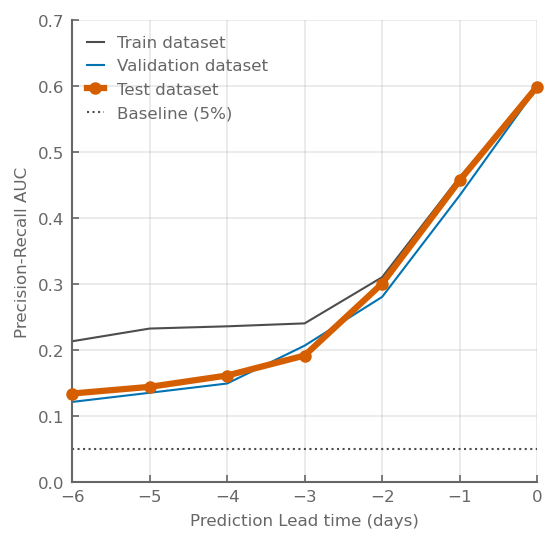

In [48]:
auc_train = []
auc_val = []
auc_test = []

for k in range(7):
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='train').targets.dropna('time')[:,k], ds_predictions.sel(dataset='train').predictions.dropna('time')[:,k])
    auc_train.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='val').targets.dropna('time')[:,k], ds_predictions.sel(dataset='val').predictions.dropna('time')[:,k])
    auc_val.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='test').targets.dropna('time')[:,k], ds_predictions.sel(dataset='test').predictions.dropna('time')[:,k])
    auc_test.append(sklearn.metrics.auc(r,p))

fig, ax = plt.subplots(figsize=(4,4,))

ax.plot(np.arange(0,-7,-1),auc_train, color='.3', label='Train dataset')
ax.plot(np.arange(0,-7,-1),auc_val, label='Validation dataset')
ax.plot(np.arange(0,-7,-1),auc_test, color='C3', lw=3, label='Test dataset', marker='o', markersize=5, clip_on=False, zorder=100)
ax.grid(ls='-', alpha=.3)
ax.axhline(0.05,color='.3' , label='Baseline (5%)', ls=':')
ax.set_xlim(-6,0)
ax.set_ylim(0,0.7)
ax.legend()
ax.set_ylabel('Precision-Recall AUC')
ax.set_xlabel('Prediction Lead time (days)')

Text(0.5, 0, 'Prediction Lead time (days)')

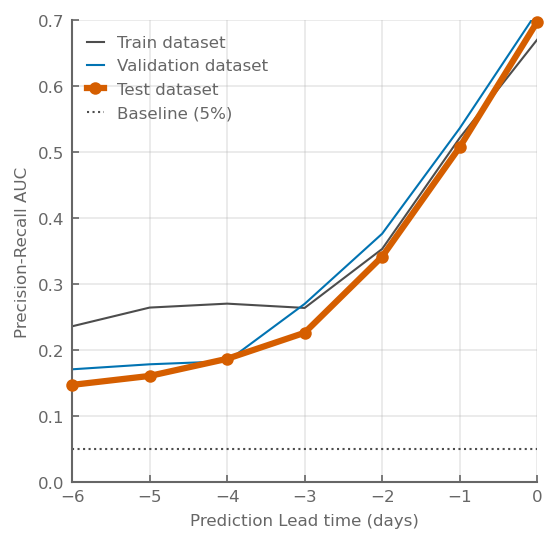

In [49]:
auc_train = []
auc_val = []
auc_test = []

for k in range(7):
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='train').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='train').predictions.dropna('time')[:,k])
    auc_train.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='val').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='val').predictions.dropna('time')[:,k])
    auc_val.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='test').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='test').predictions.dropna('time')[:,k])
    auc_test.append(sklearn.metrics.auc(r,p))

fig, ax = plt.subplots(figsize=(4,4,))

ax.plot(np.arange(0,-7,-1),auc_train, color='.3', label='Train dataset')
ax.plot(np.arange(0,-7,-1),auc_val, label='Validation dataset')
ax.plot(np.arange(0,-7,-1),auc_test, color='C3', lw=3, label='Test dataset', marker='o', markersize=5, clip_on=False, zorder=100)
ax.grid(ls='-', alpha=.3)
ax.axhline(0.05,color='.3' , label='Baseline (5%)', ls=':')
ax.set_xlim(-6,0)
ax.set_ylim(0,0.7)
ax.legend()
ax.set_ylabel('Precision-Recall AUC')
ax.set_xlabel('Prediction Lead time (days)')

In [16]:
ds_predictions.targets.to_series().value_counts()/ds_predictions.targets.to_series().value_counts().sum()

targets
0.0    0.949897
1.0    0.050103
Name: count, dtype: float64

Text(0.5, 0, 'Prediction Lead time (days)')

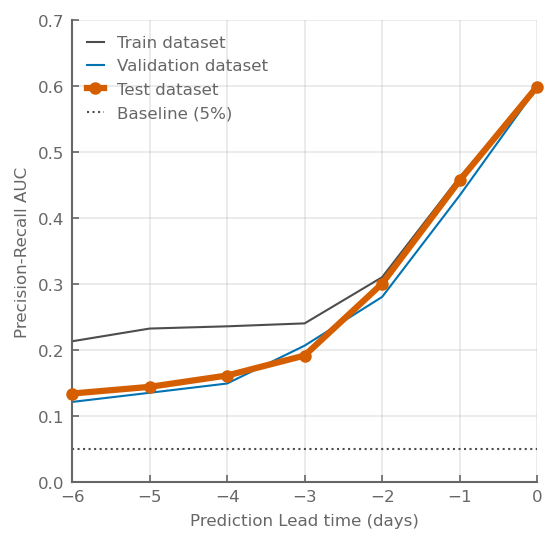

0.5957184303830559
0.46272025139175066
0.31086837801621076
0.24090667504873142
0.2364478062597061
0.23305742711760288
0.21378528796604804


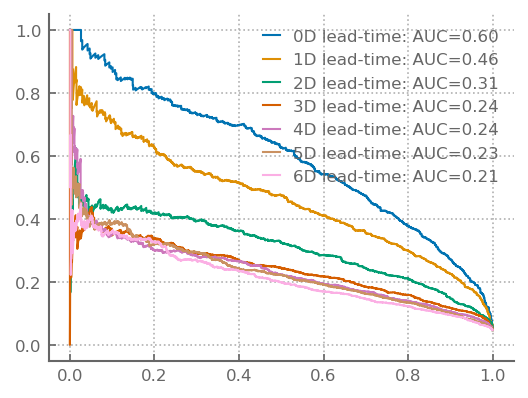

In [9]:
fig, axs = plt.subplots()
import sklearn 
for k in range(7):
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='train').targets.dropna('time')[:,k], ds_predictions.sel(dataset='train').predictions.dropna('time')[:,k])
    plt.plot(r,p, label=f'{k}D lead-time: AUC={sklearn.metrics.auc(r,p):.02f}')
    print(sklearn.metrics.auc(r,p))
plt.grid()
plt.legend()

# targets

# Plot 1: attributions are aggregated

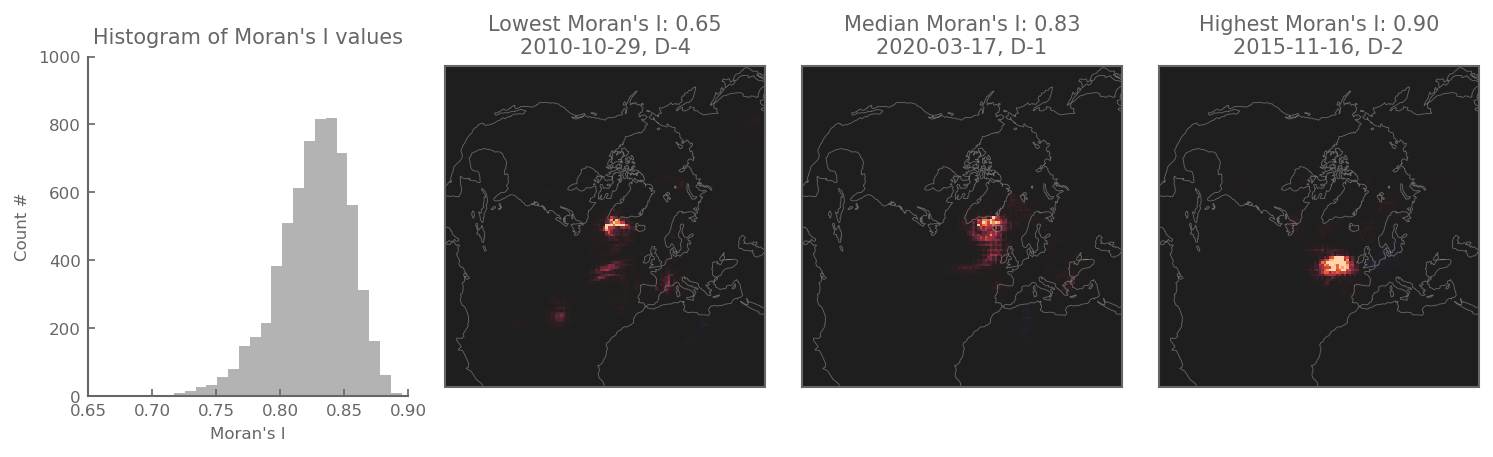

In [369]:
# print(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmax().values)
# print(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmin().values)
fig, axs = plt.subplot_mosaic("""ABCD""", figsize=(10,3), 
                              per_subplot_kw=dict(BCD=dict(projection=proj)))
ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmax()

ds_attrs.moran_I.plot.hist(ax=axs['A'], bins=30, color='.7')
ds_attrs.sel(time_of_event='2010-10-29', timestep_past=-4).lrp_normed.plot(ax=axs['B'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.008)
ds_attrs.sel(time_of_event='2020-03-17', timestep_past=-1).lrp_normed.plot(ax=axs['C'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.008)
ds_attrs.sel(time_of_event='2015-11-16', timestep_past=-2).lrp_normed.plot(ax=axs['D'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.008)


lowest_moran = ds_attrs.sel(time_of_event='2010-10-29', timestep_past=-4).moran_I.values
median_moran = ds_attrs.sel(time_of_event='2020-03-17', timestep_past=-1).moran_I.values
highest_moran = ds_attrs.sel(time_of_event='2015-11-16', timestep_past=-2).moran_I.values

for letter in 'BCD':
    axs[letter].coastlines(color='.7', lw=.4, alpha=.5)
axs['A'].set_title('Histogram of Moran\'s I values')
axs['A'].set(xlabel="Moran's I", ylabel='Count #', xlim=(.65,.9), ylim=(0,1000))
axs['B'].set_title(f'Lowest Moran\'s I: {lowest_moran:.02f}\n2010-10-29, D-4')
axs['C'].set_title(f'Median Moran\'s I: {median_moran:.02f}\n2020-03-17, D-1')
axs['D'].set_title(f'Highest Moran\'s I: {highest_moran:.02f}\n2015-11-16, D-2')
plt.tight_layout()
plt.savefig('plots/moranI_examples_lrp_normed_v2.png', dpi=300, transparent=True)

# Plot 2: example to get to blobs and cyclones

/tmp/ipykernel_2065267/231001754.py:13: FutureWarning: The behavior of 'isin' with dtype=datetime64[ms] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  gdf_cyclones_event = gdf_cyclones.query("time_of_event=='2024-12-18' and timestep_past==-2")
/tmp/ipykernel_2065267/231001754.py:14: FutureWarning: The behavior of 'isin' with dtype=datetime64[ms] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  cyclones_day = all_cyclones.query("date=='2024-12-16'")
/tmp/ipykernel_2065267/231001754.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ms] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype 

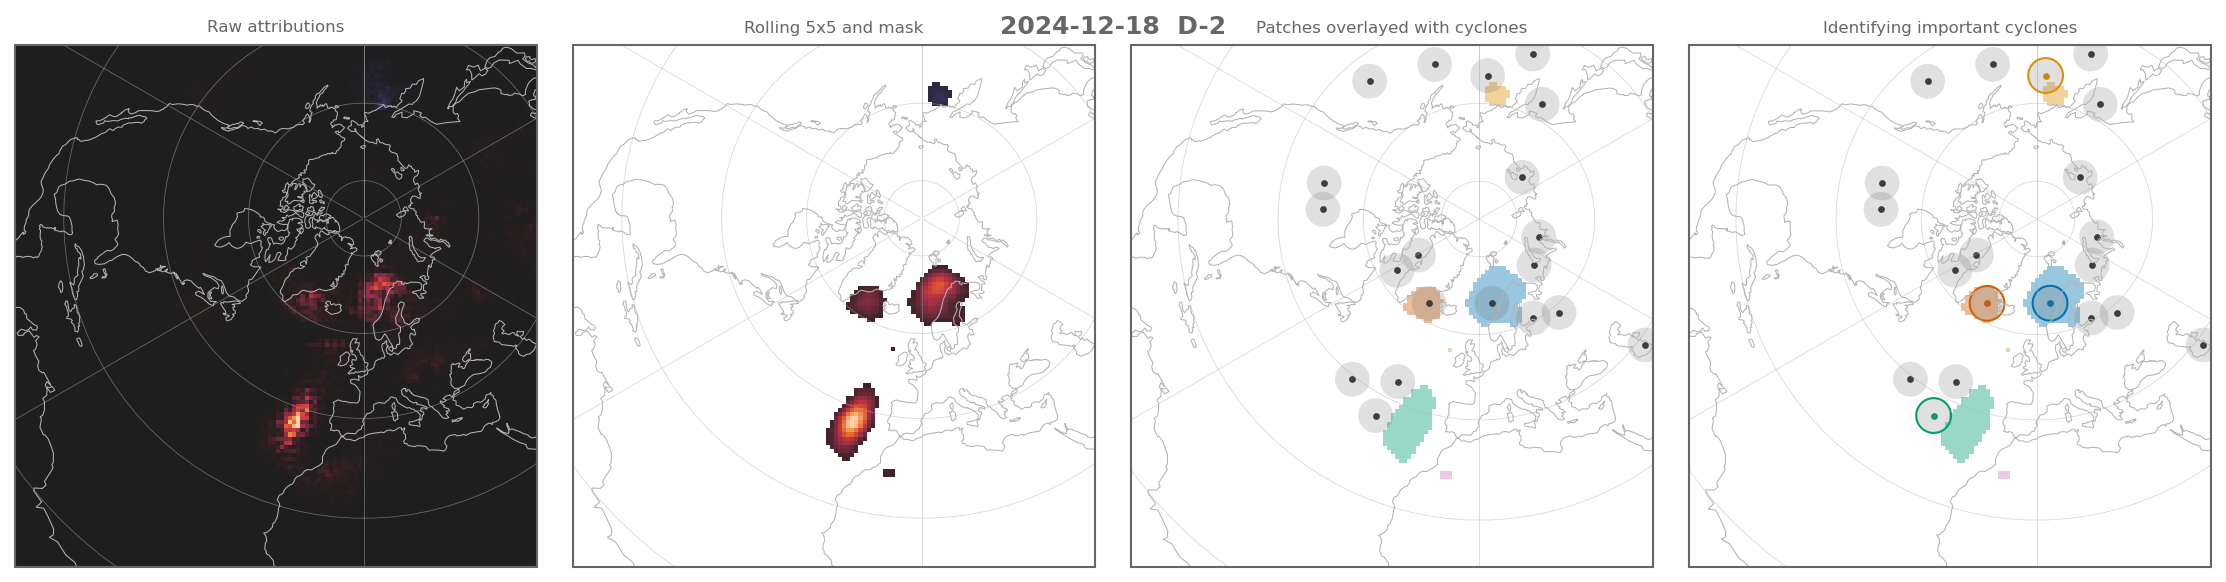

In [505]:
fig, axs = plt.subplot_mosaic("""ABCD""",figsize=(15,4), per_subplot_kw=dict(ABCD=dict(projection=proj)))
data = ds_attrs.lrp_normed.sel(time_of_event='2024-12-18', timestep_past=-2)

data.plot(cmap='icefire', ax=axs['A'], transform=proj, add_colorbar=False)

rolling=5
abs_threshold=0.0005
data_rolling = data.rolling(x=rolling,y=rolling,center=True).mean().fillna(0)
data_rolling = data_rolling.where(np.abs(data_rolling)>abs_threshold)
data_rolling = data_rolling/data_rolling.max()
data_rolling.plot(cmap='icefire', ax=axs['B'], transform=proj, add_colorbar=False)

gdf_cyclones_event = gdf_cyclones.query("time_of_event=='2024-12-18' and timestep_past==-2")
cyclones_day = all_cyclones.query("date=='2024-12-16'")
cyclone_blobs = all_cyclones.query("date=='2024-12-16'").set_index('track_id').loc[gdf_cyclones_event.query("is_cyclone").cyclone_track_id.values.astype(float)]
cyclone_no_blobs = all_cyclones.query("date=='2024-12-16'").set_index('track_id').drop(cyclone_blobs.index)


axs['C'].set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)
axs['D'].set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)

# sns.scatterplot(all_cyclones.query("date=='2024-12-16'"), x='x', y='y', ax=axs['D'], transform=proj)
for k in range(gdf_cyclones_event.index.size):
    line = gdf_cyclones_event.iloc[k:k+1]
    line.plot(color=f"C{k}", ax=axs['C'], transform=proj, alpha=.4)
    # if line.cyclone_track_id.values[0]!='No cyclone':
    #     cyclone_ = cyclone_blobs.loc[line.cyclone_track_id.astype(float).values]
    #     cyclone_.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color=f'C{k}')
    #     cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)
    #     cyclone_.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='none',edgecolor=f'C{k}', )
        # cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)

cyclones_day.query("date=='2024-12-16'").geometry.plot(aspect=1, ax=axs['C'], transform=proj, markersize=5, color='.2')
cyclones_day.query("date=='2024-12-16'").geometry.buffer(500_000).plot(aspect=1, ax=axs['C'], transform=proj, color='.4', alpha=.2)

for k in range(gdf_cyclones_event.index.size):
    line = gdf_cyclones_event.iloc[k:k+1]
    line.plot(color=f"C{k}", ax=axs['D'], transform=proj, alpha=.4)
    if line.cyclone_track_id.values[0]!='No cyclone':
        cyclone_ = cyclone_blobs.loc[line.cyclone_track_id.astype(float).values]
        cyclone_.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color=f'C{k}')
        cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)
        cyclone_.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='none',edgecolor=f'C{k}', )
        # cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)

cyclone_no_blobs.query("date=='2024-12-16'").geometry.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color='.2')
cyclone_no_blobs.query("date=='2024-12-16'").geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)

# cyclone_blobs.query("date=='2024-12-16'").geometry.plot(aspect=1, ax=axs['D'], transform=proj, markersize=15, color='C3')
# cyclone_blobs.query("date=='2024-12-16'").geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='none',edgecolor='.3')

for letter in 'ABCD':
    ax = axs[letter]
    ax.set_title('')
    ax.coastlines(color='.7', lw=.5)
    # sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,       # add tick labels
        linewidth=0.4,
        linestyle="-",
        alpha=0.5,
        zorder=2,
        color='.7'
    )
axs['A'].set_title('Raw attributions', size=8)
axs['B'].set_title('Rolling 5x5 and mask', size=8)
axs['C'].set_title('Patches overlayed with cyclones', size=8)
axs['D'].set_title('Identifying important cyclones', size=8)

plt.suptitle('2024-12-18  D-2', weight = 'bold', size=12, y=.95)
plt.tight_layout()
plt.savefig('plots/example_workflow.png', dpi=300, transparent=True)

# Plot 3.0: patches distribution


/tmp/ipykernel_2065267/236163601.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = gdf_cyclones.groupby([pd.cut(gdf_cyclones.blob_pixel_count, np.arange(0,1001,5)),


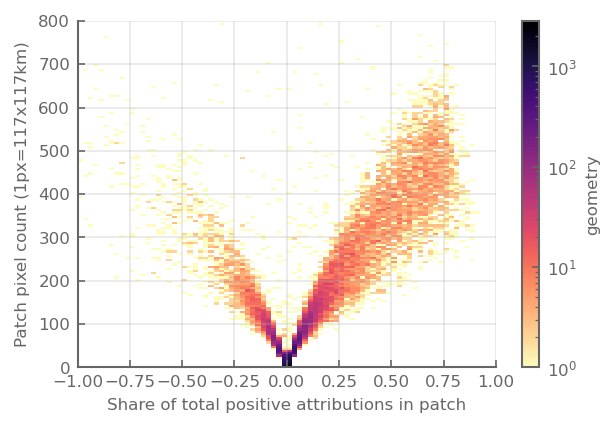

In [501]:
fig, ax = plt.subplots(figsize=(4.5,3))
df_plot = gdf_cyclones.groupby([pd.cut(gdf_cyclones.blob_pixel_count, np.arange(0,1001,5)),
                      pd.cut(gdf_cyclones.blob_attributions, np.arange(-1.5,1.1, .025)),
                      ]).geometry.count().to_xarray()
df_plot.where(df_plot>=1).plot(norm=LogNorm(), vmin=1, cmap='magma_r')
ax.grid(linestyle='-', alpha=.3, zorder=10)
ax.set(ylim=(0,800), xlim=(-1,1))
# ax.set_ylim(0,50)
ax.set_ylabel('Patch pixel count (1px=117x117km)')
ax.set_xlabel('Share of total positive attributions in patch')
plt.savefig('plots/patches_distributions.png', dpi=300, transparent=True)

# Plot 3: there are usually 1-3 large blobs per prediction
"Large blobs" are defined as 25pixels minimum (5x5 square)

In [513]:
categories = np.array(['                     ' for k in gdf_cyclones.index])
categories[((gdf_cyclones.blob_pixel_count<25)).values] = 'small blob'
categories[((np.abs(gdf_cyclones.blob_attributions)<.05)&(gdf_cyclones.blob_pixel_count>=25)).values] = 'large neutral'
categories[((gdf_cyclones.blob_attributions<-.05)&(gdf_cyclones.blob_pixel_count>=25)).values] = 'large negative'
categories[((gdf_cyclones.blob_attributions>.05)&(gdf_cyclones.blob_pixel_count>=25)).values] = 'large positive'
gdf_cyclones['blob_category'] = categories
# gdf_cyclones.category.value_counts().plot.bar()

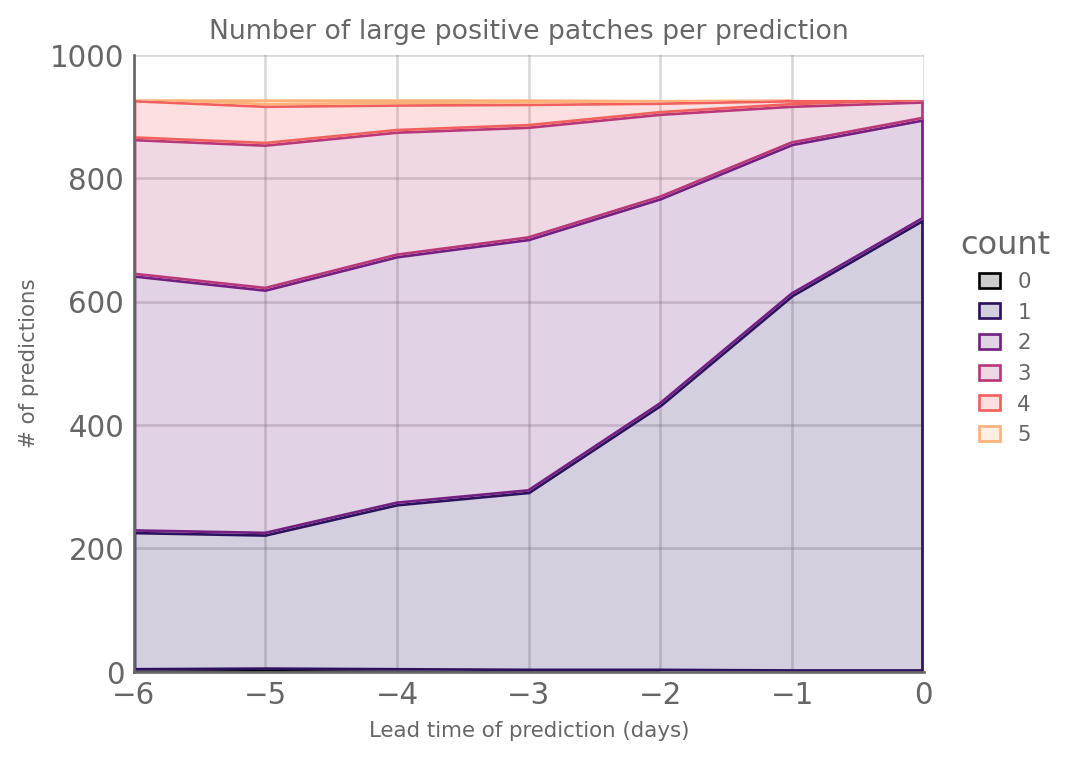

In [551]:
df_plot = gdf_cyclones.query("blob_category=='large positive'").groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')
df_count_all = gdf_cyclones.groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')*0
df_count_all.loc[df_plot.index] =df_plot
df_plot = df_count_all.reset_index()

(so.Plot(df_plot, x='timestep_past', color='count')
 .add(so.Area(), so.Count(), so.Stack(), legend=True)
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
#  .add(so.Dot(), so.Count(), so.Stack())
#  .facet(col='blo_category')
 .scale(color=so.Nominal(['0']+list(sns.color_palette('magma', n_colors=5)), order=[0,1,2,3,4,5], ) )
 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,1000))
 .label(title='Number of large positive patches per prediction', y='# of predictions', x='Lead time of prediction (days)', legend='Number of large positive blobs')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).plot().save('plots/N_large_patches_per_predictions.svg', dpi=300, transparent=True)

# plt.savefig('plots/N_large_patches_per_predictions.png', dpi=300, transparent=True)

# Plot 4: large blobs are almost always associated with cyclones

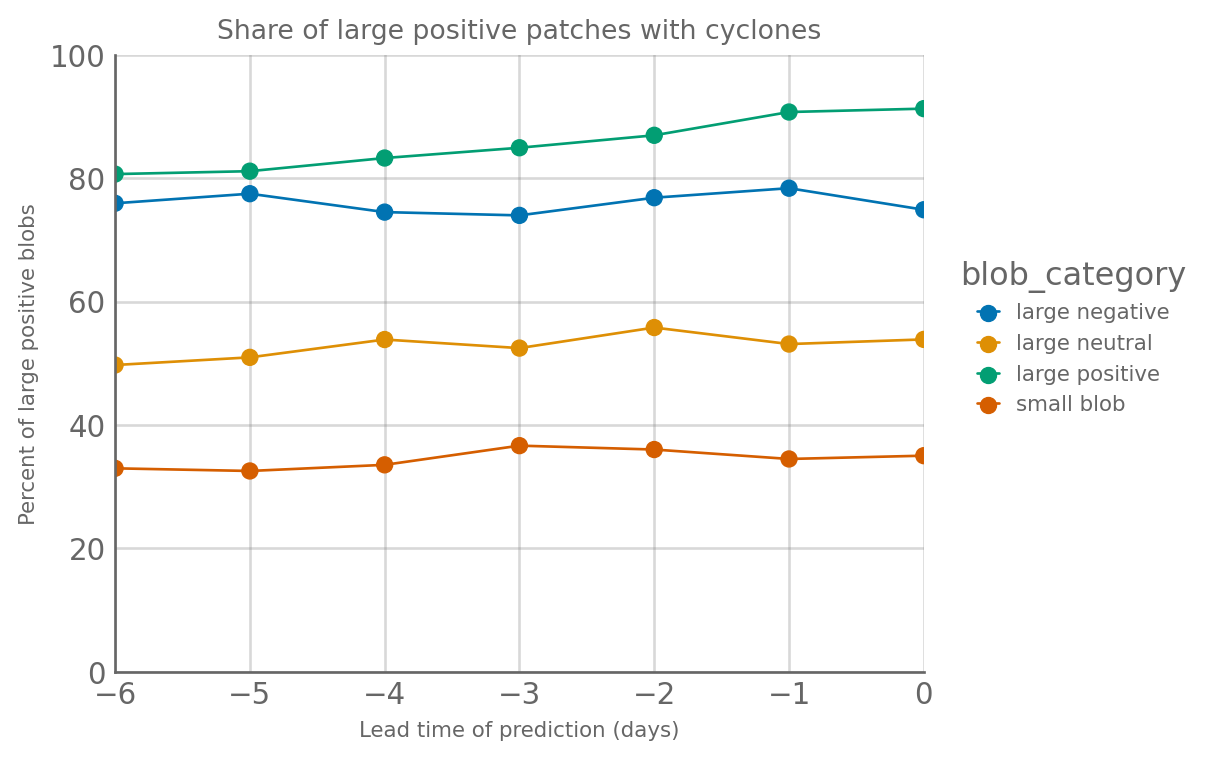

In [552]:
df_plot = (100*(gdf_cyclones.query("is_cyclone").groupby(["blob_category","timestep_past",]).blob_area.count().rename('count'))/(gdf_cyclones.groupby(["blob_category","timestep_past",]).blob_area.count().rename('count'))).rename('percentage').reset_index()

df_plot

(so.Plot(df_plot, x='timestep_past', color='blob_category', y='percentage')
 .add(so.Line(),  legend=True)
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
 .add(so.Dot(),)
#  .facet(col='blob_category')
#  .scale(color=so.Nominal(['0', 'C3']  ) )
 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,100))
 .label(title='Share of large positive patches with cyclones', y='Percent of large positive blobs', x='Lead time of prediction (days)', legend='Number of large positive blobs', yticks= '{.0f%}%')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).plot().save('plots/share_of_patches_with_cyclones.svg', dpi=300, transparent=True)


# Plot 5: there are usually 1-2 cyclones used per prediction

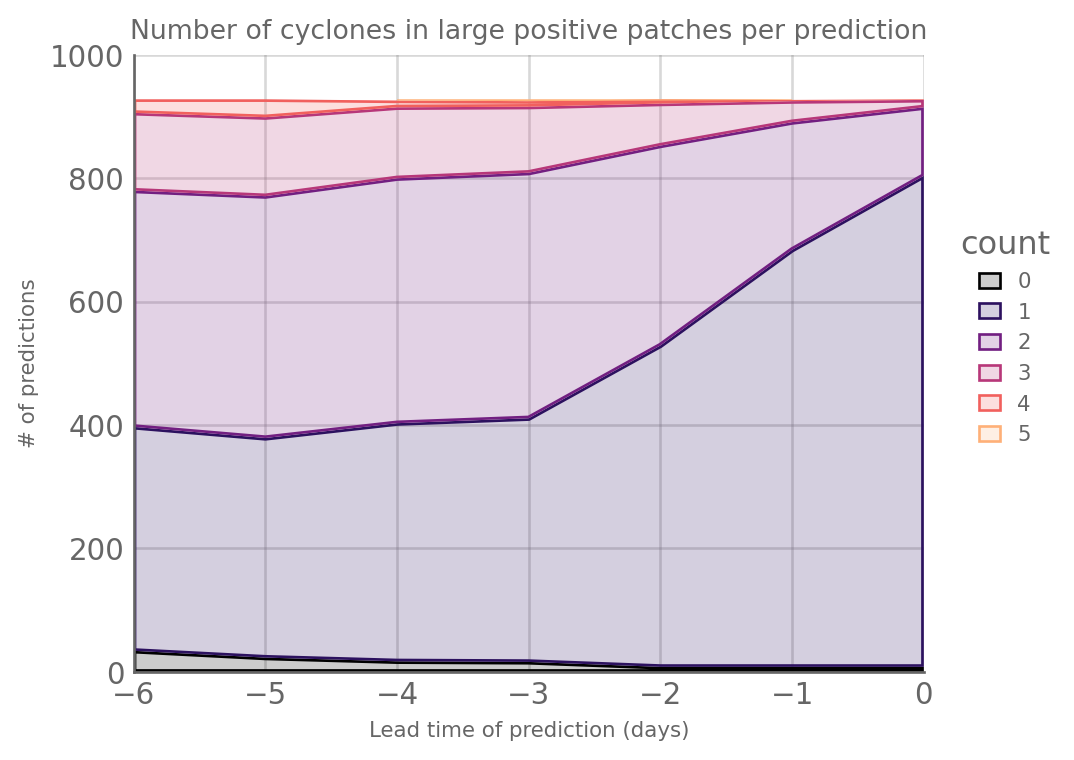

In [553]:
df_plot = gdf_cyclones.query("(blob_category=='large positive') & (is_cyclone)").groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')
df_count_all = gdf_cyclones.groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')*0
df_count_all.loc[df_plot.index] =df_plot
df_plot = df_count_all.reset_index()

(so.Plot(df_plot, x='timestep_past', color='count')
 .add(so.Area(), so.Count(), so.Stack(), legend=True)
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
#  .add(so.Dot(), so.Count(), so.Stack())
#  .facet(col='blo_category')
 .scale(color=so.Nominal(['0']+list(sns.color_palette('magma', n_colors=5)), order=[0,1,2,3,4,5], ) )
 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,1000))
 .label(title='Number of cyclones in large positive patches per prediction', y='# of predictions', x='Lead time of prediction (days)', legend='Number of large positive blobs')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).plot().save('plots/cyclones_in_patches_per_prediction.svg', dpi=300, transparent=True)



# Cyclones are in the right place
need map here

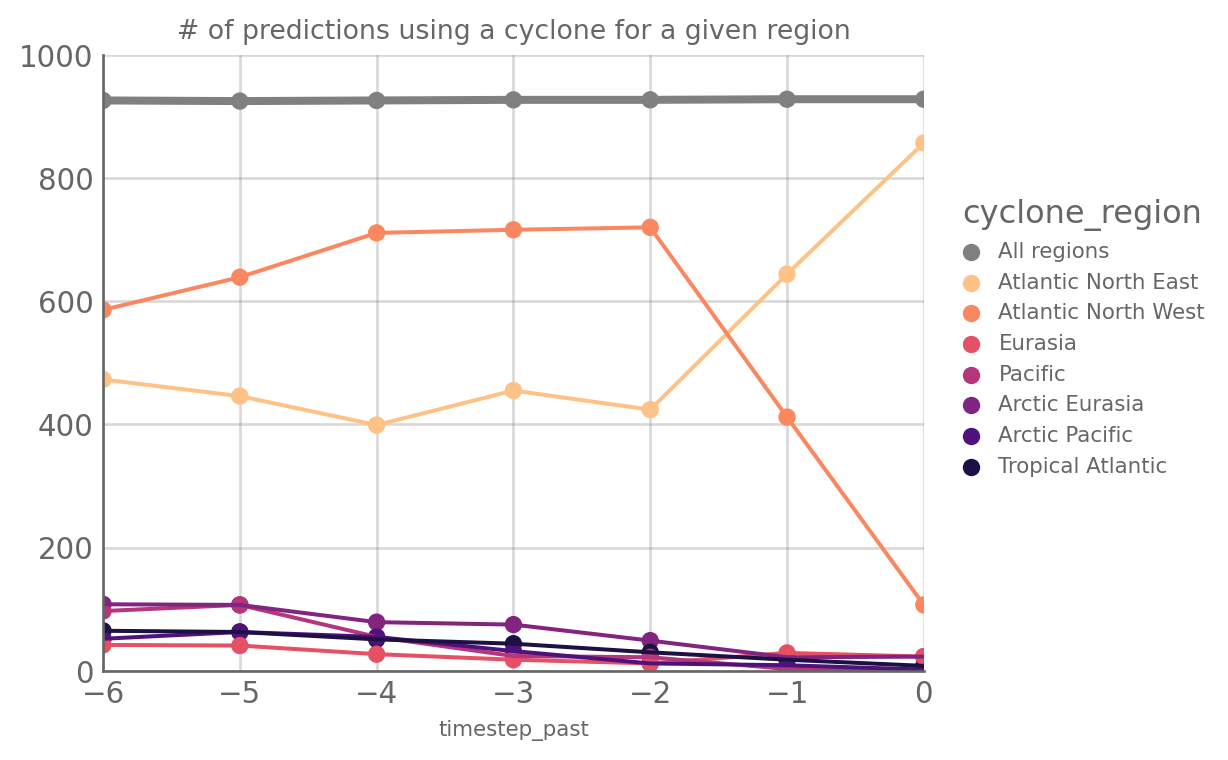

In [561]:
df_counts = gdf_cyclones.reset_index().query("blob_category=='large positive'").groupby(['time_of_event','timestep_past','cyclone_region']).cyclone_msl.count().reset_index()
df_all_counts = gdf_cyclones.reset_index().query("blob_category=='large positive'").groupby(['time_of_event','timestep_past']).cyclone_msl.count().reset_index()
df_all_counts['cyclone_region'] = 'All regions'
df_counts = pd.concat([df_counts, df_all_counts])

(so.Plot(df_counts, x='timestep_past', color='cyclone_region', linewidth='cyclone_region')
 .add(so.Lines(), so.Count(),  legend=False)
#  .add(so.Line(linewidth=3), so.Count(), , data=df_all_counts)
 .add(so.Dot(), so.Count(), )
#  .facet(col='blo_category')
 .scale(color=so.Nominal(['.5']+ sns.color_palette('magma_r', n_colors=7),order=['All regions','Atlantic North East','Atlantic North West',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic']),
       linewidth=so.Nominal([1.5,1.5,1.5,1.5,1.5,1.5,1.5,3],order=['Atlantic North West','Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic','All regions'])
       )

 .layout(size=(5,4))
  .limit(x=(-6,0), y=(0,1000))
 .label(title='# of predictions using a cyclone for a given region')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 .label(legend="Measurement")
 ).plot().save('plots/cyclone_area.svg', dpi=300, transparent=True)


# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)
